# Pull new metrics from mccray
First based off 'Original Transcript'

In [70]:
import pandas as pd
import re, nltk, csv
from nltk.corpus import words, PlaintextCorpusReader
import matplotlib.pyplot as plt

In [16]:
# pull entire dataset
# df = pd.read_csv("../data/mccray/october_sprint/mccray d_main.csv")
# df = pd.read_csv("../data/mccray/october_sprint/D_mcc_main_v2.csv")

df = pd.read_csv("test.csv")

print(f"df len: {len(df)}")
print(list(df))

# # nltk base
# # # nltk.download('words')
# english_vocab = set(w.lower() for w in words.words())

# improved ntlk corpus
wordslist = PlaintextCorpusReader('../data/mccray', 'combined_words_corpus.txt')
english_vocab = set(w.lower() for w in wordslist.words())

def save_csv(df, title):
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

print(len(df))

df len: 14427
['Title', 'Creator', 'Contributors', 'Date', 'Approximate Date', 'Source', 'Subject', 'Local Subject', 'S.C. County', 'Description', 'Extent', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path', 'Year', 'Original Transcript', 'Original Len', 'Special Pattern', 'General Pattern', 'Repeat Chars', 'Short/No Transcript', 'Quality', 'Issue Types', 'Detected Artifacts', 'D_mcc_cleaned_v1', 'sc_v1_len', 'D_mcc_cleaned_v2', 'sc_v2_len']
14427


In [17]:
title = 'Title'
descrip = 'Description'

# Function to apply re pattern
def re_pattern(text, pattern):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    total = len(text)
    matches = len(pattern.findall(text))
    return (matches / total) * 100

# patterns
# alphanum_standard = re.compile(r'[a-zA-Z0-9\s.,!?;:\'"()\-_/]')
alphanum_standard = re.compile(r'[a-zA-Z0-9\s!-/:-@[-`{-~]')
alpha_only = re.compile(r'[a-zA-Z]')

# nltk en
def percent_real_english_nltk(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    tokens = re.findall(r"[A-Za-z]{2,}", text.lower())
    if not tokens:
        return 0
    real = [t for t in tokens if t in english_vocab]
    return 100 * len(real) / len(tokens)

def english_nltk_metrics(text, vocab):
    """Return dict showing which tokens are recognized or not (NLTK-style regex)."""
    if not isinstance(text, str) or not text.strip() or not isinstance(text, str) or len(text) == 0:
        return {"valid_words": [], "not_words": [], "word_count": 0, "valid_word_count": 0, "percentage": 0, "total_chars_count_from_valid_words": 0}
    tokens = re.findall(r"[A-Za-z]{2,}", text.lower())
    word_count = len(tokens)
    valid_words, not_words = [], []
    total_chars_count_from_valid_words = 0
    for t in tokens:
        if t in vocab:
            valid_words.append(t)
            total_chars_count_from_valid_words = total_chars_count_from_valid_words + len(t)
        else:
            found_variant = False
            if len(t) > 3:
                # Handle plural forms like "stories" -> "story" 
                if t.endswith("ies") or t.endswith("iest"): 
                    if t.endswith("ies"):
                        candidate = t[:-3] + "y"
                    else:
                        candidate = t[:-4] + "y"
                    if candidate in vocab :
                        valid_words.append(t)
                        found_variant = True
                # Only check other trims if no variant found yet
                if not found_variant:
                    for i in range(1, 4):  # remove 1–3 chars
                        base = t[:-i]
                        if base in vocab:
                            valid_words.append(t)
                            found_variant = True
                            break  # stop checking further
            if not found_variant:
                not_words.append(t)
            else:
                total_chars_count_from_valid_words = total_chars_count_from_valid_words + len(t)
    valid_word_count = len(valid_words)
    if len(tokens) == 0:
        percentage = 0
    else:
        percentage = 100 * len(valid_words) / len(tokens)
    return {"valid_words": valid_words, "not_words": not_words, "word_count":word_count, "valid_word_count":valid_word_count, "percentage": percentage, "total_chars_count_from_valid_words": total_chars_count_from_valid_words}


In [18]:
# Title 
df['% alphanum_standard title'] = df[title].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only title'] = df[title].apply(lambda x: re_pattern(x, alpha_only))
df['% en title'] = df[title].apply(percent_real_english_nltk)

# Description
df['% alphanum_standard descrip'] = df[descrip].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only descrip'] = df[descrip].apply(lambda x: re_pattern(x, alpha_only))
df['% en descrip'] = df[descrip].apply(percent_real_english_nltk)

In [19]:
# Transcripts
og_tr = "Original Transcript"
sc_tr_v1 = 'D_mcc_cleaned_v1'
sc_tr_v2 = 'D_mcc_cleaned_v2'

# alphanumeric + ascii sumbols
df['% alphanum_standard D_mcc_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alphanum_standard D_mcc_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alphanum_standard D_mcc_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alphanum_standard))

# alphabet a-Z
df['% alpha_only D_mcc_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alpha_only))
df['% alpha_only D_mcc_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alpha_only))
df['% alpha_only D_mcc_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alpha_only))

# More advanced word checks
df[['og_valid_words', 'og_not_words', 'og_word_count', 'og_valid_word_count', 'og_percentage', 'og_total_chars_count_from_valid_words']] = df[og_tr].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v1_valid_words', 'sc_v1_not_words', 'sc_v1_word_count', 'sc_v1_valid_word_count', 'sc_v1_percentage', 'sc_v1_total_chars_count_from_valid_words']] = df[sc_tr_v1].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v2_valid_words', 'sc_v2_not_words', 'sc_v2_word_count', 'sc_v2_valid_word_count', 'sc_v2_percentage', 'sc_v2_total_chars_count_from_valid_words']] = df[sc_tr_v2].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df['max_word_count_value'] = df[['og_word_count', 'sc_v1_word_count', 'sc_v2_word_count']].max(axis=1)

# Calculate each version's valid word count as percentage of max
df['% og_valid_words'] = (df['og_valid_word_count'] / df['max_word_count_value'] *100)
df['% sc_v1_valid_words'] = (df['sc_v1_valid_word_count'] / df['max_word_count_value']*100)
df['% sc_v2_valid_words'] = (df['sc_v2_valid_word_count'] / df['max_word_count_value']*100)

# Calculate Chars in Valid Words Percentage (valid word chars / total char count)
df['og_valid_words_char_percentage'] = (df['og_total_chars_count_from_valid_words'] / df['Original Len']*100)
df['sc_v1_valid_words_chars_percentage'] = (df['sc_v1_total_chars_count_from_valid_words'] / df['sc_v1_len']*100)
df['sc_v2_valid_words_chars_percentage'] = (df['sc_v2_total_chars_count_from_valid_words'] / df['sc_v2_len']*100)

# Calculate Chars in Valid Words Percentage (valid word chars / alpa only chars count)
df['og_valid_words_alphachars_percentage'] = (df['og_total_chars_count_from_valid_words'] / df[og_tr].apply(lambda x: len(alpha_only.findall(str(x)))) * 100)
df['sc_v1_valid_words_alphachars_percentage'] = (df['sc_v1_total_chars_count_from_valid_words'] / df[sc_tr_v1].apply(lambda x: len(alpha_only.findall(str(x)))) * 100)
df['sc_v2_valid_words_alphachars_percentage'] = (df['sc_v2_total_chars_count_from_valid_words'] / df[sc_tr_v2].apply(lambda x: len(alpha_only.findall(str(x)))) * 100)

In [20]:
df[0:10]

,Title,Creator,Contributors,Date,Approximate Date,Source,Subject,Local Subject,S.C. County,Description,...,max_word_count_value,% og_valid_words,% sc_v1_valid_words,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_valid_words_alphachars_percentage,sc_v1_valid_words_alphachars_percentage,sc_v2_valid_words_alphachars_percentage
0,Afro-American Newsboy Application signed by Mr...,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,An application to be a Newsboy for the Afro-Am...,...,35,100.000000,100.000000,100.000000,93.427230,93.427230,93.427230,99.004975,99.004975,99.004975
1,Lighthouse Informer receipt,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,A blank Lighthouse and Informer receipt.,...,18,100.000000,100.000000,100.000000,81.818182,83.193277,81.818182,95.192308,95.192308,95.192308
2,"The Lighthouse Solicitor's Record, Home Office...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,"A solicitor's record, home office order, and s...",...,68,100.000000,100.000000,100.000000,90.816327,91.516710,90.816327,98.888889,98.888889,98.888889
3,The Lighthouse Remittance Envelope(Front),NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,The front of a Lighthouse remittance envelope.,...,9,100.000000,100.000000,100.000000,70.833333,70.833333,70.833333,89.473684,89.473684,89.473684
4,"Advertisment, Chicken Special at the Pig Trail...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,An ad about the Chicken Special for the Pig Tr...,...,33,96.969697,96.969697,96.969697,85.093168,86.163522,85.093168,98.561151,98.561151,98.561151
5,"The Lighthouse Solicitor's Record, Home Office...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,"A solicitor's record, home office order, and s...",...,68,100.000000,100.000000,100.000000,90.816327,91.516710,90.816327,98.888889,98.888889,98.888889
6,The Lighthouse Prospectus,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,A prospectus of the Lighthouse with permanent ...,...,96,100.000000,100.000000,100.000000,90.327613,91.037736,90.327613,99.827586,99.827586,99.827586
7,The Lighthouse Temporary and Permanent Operati...,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,Temporary and Permanent Operating Costs includ...,...,28,85.714286,85.714286,85.714286,66.141732,72.413793,66.141732,87.046632,87.046632,87.046632
8,"Letter, Lighthouse Newspaper Sign-up Sheet sen...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,A sign-up sheet for the Lighthouse Newspaper s...,...,37,100.000000,100.000000,100.000000,91.707317,92.156863,91.707317,98.429319,98.429319,98.429319
9,"Letter, Lighthouse Newspaper Sign-up Sheet sen...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,A sign-up sheet for the Lighthouse Newspaper s...,...,37,100.000000,100.000000,100.000000,92.380952,92.822967,92.380952,98.477157,98.477157,98.477157


In [21]:
# Save
# save_csv(df, "new_metrics main -- all.csv")
save_csv(df, "test metrics.csv")

In [22]:
# Averages
def column_stats(df, colname):
    """
    Returns basic statistics (min, mean, median, max, percentiles) for a numeric column.
    """
    if colname not in df.columns:
        raise ValueError(f"Column '{colname}' not found in DataFrame.")
    
    # Drop NaN values to avoid errors
    series = pd.to_numeric(df[colname], errors='coerce').dropna()

    if series.empty:
        return {"min": None, "p10": None, "p25": None, "mean": None, "median": None, "max": None}
    
    stats = {
        "min": series.min(),
        "p10": series.quantile(0.10),
        "p25": series.quantile(0.25),
        "mean": series.mean(),
        "median": series.median(),
        "max": series.max()
    }
    
    print(f"\nStats for column: **{colname}**")
    print("-" * 40)
    print(f"Minimum:        {stats['min']:.2f}")
    print(f"10th percentile: {stats['p10']:.2f}")
    print(f"25th percentile: {stats['p25']:.2f}")
    print(f"Mean:           {stats['mean']:.2f}")
    print(f"Median:         {stats['median']:.2f}")
    print(f"Maximum:        {stats['max']:.2f}")
    print("-" * 40)

    return stats

check_cols = [
    "% alphanum_standard title",
    "% alpha_only title",
    "% en title",
    "% alphanum_standard descrip",
    "% alpha_only descrip",
    "% en descrip",
    "% alphanum_standard D_mcc_raw tr",
    "% alphanum_standard D_mcc_cleaned_v1 tr",
    "% alphanum_standard D_mcc_cleaned_v2 tr",
    "% alpha_only D_mcc_raw tr",
    "% alpha_only D_mcc_cleaned_v1 tr",
    "% alpha_only D_mcc_cleaned_v2 tr",
    # "% en D_mcc_raw tr",
    # "% en D_mcc_cleaned_v1 tr",
    # "% en D_mcc_cleaned_v2 tr",
    '% og_valid_words',
    '% sc_v1_valid_words',
    '% sc_v2_valid_words',
    'og_valid_words_char_percentage',
    'sc_v1_valid_words_chars_percentage',
    'sc_v2_valid_words_chars_percentage',
    'og_valid_words_alphachars_percentage',
    'sc_v1_valid_words_alphachars_percentage',
    'sc_v2_valid_words_alphachars_percentage'
    
]

for col in check_cols:
    column_stats(df, col)

print()


Stats for column: **% alphanum_standard title**
----------------------------------------
Minimum:        78.57
10th percentile: 100.00
25th percentile: 100.00
Mean:           99.98
Median:         100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% alpha_only title**
----------------------------------------
Minimum:        0.00
10th percentile: 61.90
25th percentile: 66.33
Mean:           72.34
Median:         72.58
Maximum:        100.00
----------------------------------------

Stats for column: **% en title**
----------------------------------------
Minimum:        0.00
10th percentile: 100.00
25th percentile: 100.00
Mean:           99.73
Median:         100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% alphanum_standard descrip**
----------------------------------------
Minimum:        0.00
10th percentile: 100.00
25th percentile: 100.00
Mean:           98.65
Median:         100.00
Maximum:      

In [48]:
problem = df[
    (df['og_valid_words_alphachars_percentage'] < 50) | # 1362 rows
	(df['og_valid_word_count'] <= 1)                    # 153 rows
	
    # (df['% og_valid_words']) != (df['% sc_v2_valid_words'])
]

# less than 50 on og_valid_words_alphachars_percentage is def bad
print("problem len:", len(problem))

# display(problem[['CONTENTdm file name','Original Transcript','D_mcc_cleaned_v1','D_mcc_cleaned_v2','Quality','Original Len', 'og_valid_words_alphachars_percentage']])

problem['text'] = problem['Original Transcript'].copy()

check = problem[['CONTENTdm file name', 'text', 'og_valid_words', 'sc_v2_valid_words', '% og_valid_words', '% sc_v2_valid_words']]
display(check)

# save_csv(check, "problem check metrics.csv")

problem len: 1515


/tmp/ipykernel_7925/1937555531.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  problem['text'] = problem['Original Transcript'].copy()


,CONTENTdm file name,text,og_valid_words,sc_v2_valid_words,% og_valid_words,% sc_v2_valid_words
704,969.jp2,23/7 j┬úfa~^ J/. ^ J^r fnJM^^t^^^J^J^ **...,"[fa, obtuse, ila]",[obtuse],50.000000,16.666667
705,970.jp2,^/^V&gt; ^/^M^Ptcf Com! a*&?/9P2L fcfi^y YK&k...,"[tca, wu, of]","[tca, wu, of]",23.076923,23.076923
730,995.jp2,"10$ ┬úv*l dni/c/ Apt. f Bcoa. A*. 4*1 &*f, ┬...","[apt, dry, urnjjl, fotn]","[apt, dry, urnjjl, fotn]",26.666667,26.666667
731,996.jp2,far,[far],[far],100.000000,100.000000
732,997.jp2,G. HIT ΓÇó,[hit],[hit],100.000000,100.000000
...,...,...,...,...,...,...
14376,24753.jp2,Fsi,[],[],0.000000,0.000000
14377,24754.jp2,"i C/ - L CUT /a vC ┬ú, . Γûá: ...","[cut, tacu, cc]","[cut, tacu, cc]",14.285714,14.285714
14378,24755.jp2,Γûá Γûá -,[],[],NaN,NaN
14389,24766.jp2,\\\\&Ree \\\\JSE3&gt; LA p /┬ú-* SI2-...,"[ree, la, si]","[ree, la, si]",50.000000,50.000000


In [39]:
save_csv(problem, "problem metrics.csv")

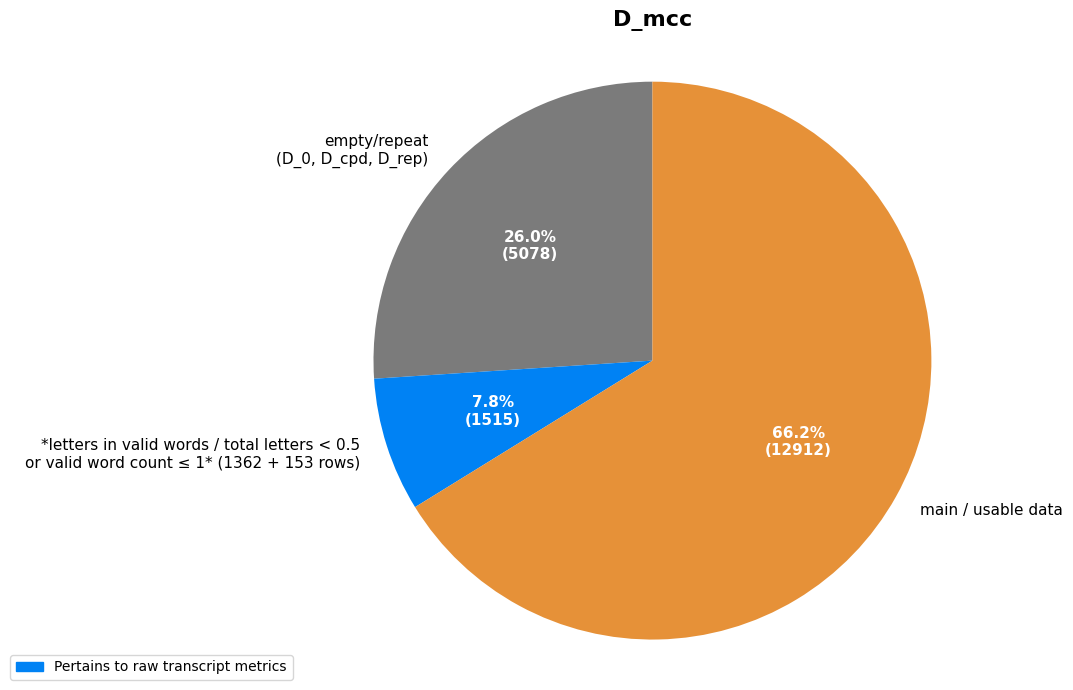

In [80]:
import matplotlib.patches as mpatches

# Counts
round_one_iso = 5078 # gray
round_two_iso = len(problem) # blue
rest = len(df) - len(problem) # orange

# data
categories = ['empty/repeat\n(D_0, D_cpd, D_rep)', '*letters in valid words / total letters < 0.5\nor valid word count ≤ 1* (1362 + 153 rows)', 'main / usable data']
values = [round_one_iso, round_two_iso, rest]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", "#0082f4", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title('D_mcc', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

red_patch = mpatches.Patch(color="#0082f4", label='Pertains to raw transcript metrics')
plt.legend(handles=[red_patch], loc='center right', bbox_to_anchor=(-0.05, 0))
plt.tight_layout()
